In [1]:
import json
from pathlib import Path
import jax
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import serialization as sz
import pandas as pd
# If you really want seaborn for styling (optional):
# import seaborn as sns; sns.set()


from model import (
    MiniGPJax,
    # kernel / mean / likelihood classes
    RBF, Matern32, GaussianLikelihood, ZeroMean, GPParams, Standardizer,
    # state (de)serializers defined in your file
    _kernel_to_state, _kernel_from_state,
    _lik_to_state, _lik_from_state,
    _zeromean_to_state, _zeromean_from_state,
    _gpparams_to_state, _gpparams_from_state,
    _std_to_state, _std_from_state,
)
from model import MiniGPJax, _register_all_serializers_once
_register_all_serializers_once()

/Users/akshayjacobthomas/anaconda3/envs/jax_trial/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Create a GP code surrogate and then save it

In [2]:
TRAIN_CSV = "11_13_25_train_set.csv"#Completed_train_set_10_30_25.csv#"Train_Set_2.csv"
TEST_CSV  = "11_13_25_test_set.csv"#"Test_Set_2.csv"
CKPT_DIR  = "ckpts/gp_run_004"
dim = 5
gp = MiniGPJax(
    dim=dim,
    kernel="rbf",            # or "matern32" I dont have the others
    fixed_noise=None,        # consider None to learn noise for better generalization
    standardize_x=True,
    standardize_y=True,
    log_y=True,              # ensures: log -> standardize (train stats) -> fit
    jitter=1e-6,
)
gp.load(TRAIN_CSV, TEST_CSV)
gp.fit(lbfgs_max_iter=30, lbfgs_tol=1e-7, num_restarts=1, seed=100)

#

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!
W0000 00:00:1763324741.521256   74009 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1763324741.533397   74009 service.cc:145] XLA service 0x60000281c500 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763324741.533414   74009 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1763324741.534748   74009 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1763324741.534758   74009 mps_client.cc:384] XLA backend will use up to 22906109952 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M2 Max
[ok] Loaded train: X=(1024, 5), y=(1024,) (log→std)
[ok] Loaded test:  X=(256, 5), y=(256,) (log→std)
[restart 0] nLML = -1943.275146
[ok] Best nLML = -1943.275146
[fit] amp=1.482 | noise_var=9.691e-06 | ell=[ 5.489  2.183 28.434  0.347  2.138]
[fit] train RMSE(z)=0.0027 | R²(z)=1.0000  (z = standardized)


In [3]:
gp.evaluate_and_plot(outdir="11_16_25")  # defaults to "log" when log_y=True


[eval:log] RMSE(log)=0.021460 | MAE(log)=0.010059 | R²(log)=0.999637


{'rmse_log': 0.021460197865962982,
 'mae_log': 0.010059233754873276,
 'r2_log': 0.9996371125229039}

In [4]:
_register_all_serializers_once()
gp.save_checkpoint(CKPT_DIR)

[save] Wrote checkpoint to: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_004


In [5]:

CKPT_DIR = "ckpts/gp_run_004"
TRAIN_CSV = "Completed_train_set_10_30_25.csv"
_register_all_serializers_once()
gp2 = MiniGPJax.ready_from_checkpoint(CKPT_DIR, train_csv=TRAIN_CSV, rebuild=True)

[load] Loaded config+params from: /Users/akshayjacobthomas/Documents/GitHub/BayesianFLow_calibration/ckpts/gp_run_004
[posterior] Rebuilt training posterior.


In [14]:
x_single = np.array([[0.68,4823,0.0039,9.9,3.45E-07]], dtype=np.float32)  # shape (1, 5)

mu, std = gp2.predict(x_single)
print(mu/1e7, std/1e7)

[1.0051284] [4.0108814]


In [2]:
df = pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Pressure")               
df.head()

subset = df.iloc[1:, 2:6]
# Make the first row the header

new_header = subset.iloc[0]   # get the first row
subset = subset[1:]           # take the data after the header row
subset.columns = new_header   # set header
subset = subset.reset_index(drop=True)  # clean index
print(subset.head())

pressure = subset['Pump Pressure(PSI)'].values[1:]
pressure_times = subset['Time(s)'].values[1:]

1   Time(s) Extruder Pressure (PSI) Pump Pressure(PSI) Temperature(C)
0         0               687.94829         332.927429     279.594642
1  0.060966              721.002479         305.609107     279.594642
2  0.108939              747.514903         285.115698     279.594642
3  0.154912               767.74587         270.662268     279.594642
4  0.200885              781.886558          261.56303     279.594642


(array([1.000e+00, 1.000e+00, 1.119e+03, 7.230e+02, 1.200e+01, 7.800e+01,
        1.363e+03, 4.850e+02, 1.000e+00, 1.000e+00]),
 array([-2.11480363, -1.53596184, -0.95712005, -0.37827827,  0.20056352,
         0.77940531,  1.35824709,  1.93708888,  2.51593067,  3.09477245,
         3.67361424]),
 <BarContainer object of 10 artists>)

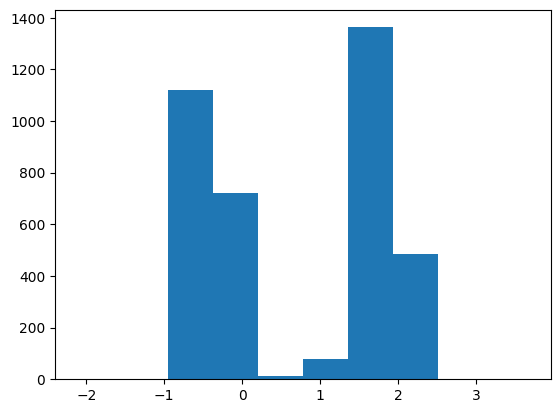

In [3]:
df= pd.read_excel("data_exploration/Mat_time_pres_pos_data_1501.xlsx", header =None, sheet_name= "Position")
df.head()
columns_to_drop = [0, 1,7, 9, 10, 11, 12]

df.drop(df.columns[columns_to_drop], axis=1, inplace=True)


subset = df.iloc[1:, :]
new_header = subset.iloc[0]
subset.columns = new_header
subset = subset.reset_index(drop=True)  # clean index
subset.head()

# xreate all the ararys 

time = subset['Time(seconds)'].values[1:]
x_locs = subset['x(mm)'].values[1:]
y_locs = subset['y(mm)'].values[1:]
z_locs = subset['z(mm)'].values[1:]
speeds = subset['Speed (mm/s)'].values[1:]
flow_rates = subset['Flowrate[m^3/s]'].values[1:]

extract_flow = 2.91582835522733e-07
mask = (flow_rates > 0.96 * extract_flow) & (flow_rates < 1.04 * extract_flow)
plt.hist((flow_rates[np.argwhere(mask)] - extract_flow)/extract_flow * 100)

In [4]:
# cleaned version of my code above from CHATGPT
def extract_layer_data(layer: int,
                       layer_height: float,
                       z_locs: np.ndarray,
                       time: np.ndarray,
                       speeds: np.ndarray,
                       flow_rates: np.ndarray,
                       pressure_times: np.ndarray,
                       pressure: np.ndarray,
                       extract_flow: float,
                       flow_sensor_error_percentage: float = 1.0):
    """
    Extracts steady-state flow and corresponding pressure data for a given layer.

    Parameters
    ----------
    layer : int
        Layer number (1-indexed).
    layer_height : float
        Height of one layer in mm.
    z_locs : np.ndarray
        Array of z-locations (same length as `time` and `flow_rates`).
    time : np.ndarray
        Array of timestamps for flow measurements.
    speeds : np.ndarray
        Array of speeds corresponding to each time.
    flow_rates : np.ndarray
        Array of flow rate measurements.
    pressure_times : np.ndarray
        Array of timestamps for pressure measurements.
    pressure : np.ndarray
        Array of pressure values.
    extract_flow : float
        Expected flow rate to extract steady-state region.
    flow_sensor_error_percentage : float, optional
        Allowed sensor error in %, default 5%.

    Returns
    -------
    dict
        Dictionary containing:
        - 'times_speeds': np.ndarray of times during steady-state
        - 'flow_rates_ss': np.ndarray of steady-state flow rates
        - 'pressure_times_ss': np.ndarray of matching pressure times
        - 'pressures_ss': np.ndarray of matching pressure values
        - 'mask_flow_rates': np.ndarray of indices of steady-state flow points
    """

    # Compute allowed flow rate range
    extract_flow_min = extract_flow * (1 - 0.01 * flow_sensor_error_percentage)
    extract_flow_max = extract_flow * (1 + 0.01 * flow_sensor_error_percentage)

    # Extract layer
    mask_layer = np.argwhere(
        (z_locs >= layer_height * (layer - 1)) & (z_locs < layer_height * layer)
    ).flatten()
    times_layer = time[mask_layer]
    speeds_layer = speeds[mask_layer]
    flow_rates_layer = flow_rates[mask_layer]

    # Steady-state flow mask
    mask_flow = np.argwhere(
        (flow_rates_layer >= extract_flow_min) & (flow_rates_layer <= extract_flow_max)
    ).flatten()
    times_speeds = times_layer[mask_flow]
    flow_rates_ss = flow_rates_layer[mask_flow]

    # Matching pressure segment
    if len(times_speeds) > 0:
        time_range = np.array([np.min(times_speeds), np.max(times_speeds)])
        mask_pressure = np.argwhere(
            (pressure_times >= time_range[0]) & (pressure_times <= time_range[1])
        ).flatten()
        pressure_times_ss = pressure_times[mask_pressure]
        pressures_ss = pressure[mask_pressure]
    else:
        pressure_times_ss = np.array([])
        pressures_ss = np.array([])

    return {
        "times_speeds": times_speeds,
        "flow_rates_ss": flow_rates_ss,
        "pressure_times_ss": pressure_times_ss,
        "pressures_ss": pressures_ss,
        "mask_flow_rates": mask_flow,
    }

In [9]:
# ---------- collect per-layer steady means ----------
n_layers = 14
means = np.full((n_layers, 4), np.nan)
sems  = np.full((n_layers, 4), np.nan)

# NEW: store per-layer average measured flow for each of the 4 flow setpoints
flow_means = np.full((n_layers, 4), np.nan)
flow_sems  = np.full((n_layers, 4), np.nan)

def pick_first_key(d: dict, candidates):
    for k in candidates:
        if k in d and d[k] is not None:
            return d[k]
    return None

for layer in range(1, n_layers + 1):
    for k, flow in enumerate(flows):
        res = extract_layer_data(
            layer=layer,
            layer_height=1.5,
            z_locs=z_locs,
            time=time,
            speeds=speeds,
            flow_rates=flow_rates,
            pressure_times=pressure_times,
            pressure=pressure,
            extract_flow=flow,
            flow_sensor_error_percentage=4.0,
        )

        # ----- pressure steady-state stats (existing) -----
        pt = res["pressure_times_ss"]
        pv = res["pressures_ss"]
        m, se = steady_mean_of_segment(pt, pv)
        means[layer-1, k] = m
        sems[layer-1, k]  = se

        # ----- flow steady-state stats (NEW) -----
        # Try to read steady-state flow directly if provided by extract_layer_data
        ft = pick_first_key(res, ["flow_times_ss", "flowrate_times_ss", "flow_rate_times_ss"]) or pt
        fv = pick_first_key(res, ["flow_rates_ss", "flowrate_ss", "flows_ss", "flow_ss"])

        if fv is None:
            # Fallback: estimate from the raw flow_rates around the commanded flow ± sensor error,
            # within the same time indices used for pressure steady-state, if available.
            # Try to get the boolean mask / indices for the steady window:
            mask_ss = pick_first_key(res, ["mask_ss", "steady_mask", "ss_mask"])
            if mask_ss is not None and mask_ss.shape == flow_rates.shape:
                cand = flow_rates[mask_ss]
            else:
                # last-resort: just band around the setpoint across all samples
                band = 0.04 * flow
                mask = (flow_rates > (flow - band)) & (flow_rates < (flow + band))
                cand = flow_rates[mask]

            if cand.size > 1:
                fm, fse = float(np.mean(cand)), float(np.std(cand, ddof=1) / np.sqrt(cand.size))
            elif cand.size == 1:
                fm, fse = float(cand[0]), np.nan
            else:
                fm, fse = np.nan, np.nan
        else:
            # We have steady-state flow vector fv (and possibly its times ft)
            fm, fse = steady_mean_of_segment(ft, fv)

        flow_means[layer-1, k] = fm
        flow_sems[layer-1, k]  = fse

# ---------- consecutive differences & error propagation (unchanged) ----------
d12 = means[:, 1] - means[:, 0]
d23 = means[:, 2] - means[:, 1]
d34 = means[:, 3] - means[:, 2]

sd12 = np.sqrt(sems[:, 1]**2 + sems[:, 0]**2)
sd23 = np.sqrt(sems[:, 2]**2 + sems[:, 1]**2)
sd34 = np.sqrt(sems[:, 3]**2 + sems[:, 2]**2)

layers = np.arange(1, n_layers + 1)

# ---------- plot (unchanged) ----------
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(layers, d12, yerr=sd12, fmt='o-', capsize=3, label=r'$\Delta 12$: F2 - F1')
ax.errorbar(layers, d23, yerr=sd23, fmt='s-', capsize=3, label=r'$\Delta 23$: F3 - F2')
ax.errorbar(layers, d34, yerr=sd34, fmt='^-', capsize=3, label=r'$\Delta 34$: F4 - F3')

for d, name, ls in [(d12, r'$\Delta 12$ mean', ':'), (d23, r'$\Delta 23$ mean', '--'), (d34, r'$\Delta 34$ mean', '-.')]:
    mu = np.nanmean(d)
    ax.axhline(mu, linestyle=ls, alpha=0.4, label=fr'{name} = {mu:.3f}')

ax.set_xlabel('Layer', fontsize=12)
ax.set_ylabel('Pressure difference', fontsize=12)
ax.set_title('Consecutive flow-rate pressure differences across layers', fontsize=13)
ax.legend(ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ---------- quick numeric summary (unchanged) ----------
def summarize(name, d, sd):
    valid = np.isfinite(d)
    mu = np.nanmean(d)
    sdv = np.nanstd(d, ddof=1)
    print(f"{name}: mean={mu:.4f}, std_across_layers={sdv:.4f}, "
          f"n={valid.sum()}, median_SE={np.nanmedian(sd):.4f}")

summarize(r"\Delta 12", d12, sd12)
summarize(r"\Delta 23", d23, sd23)
summarize(r"\Delta 34", d34, sd34)

# ---------- NEW: per-layer average flow arrays ----------
f1, f2, f3, f4 = (flow_means[:, 0], flow_means[:, 1], flow_means[:, 2], flow_means[:, 3])

NameError: name 'steady_mean_of_segment' is not defined

In [8]:
# Your flow rates
flows = np.array([
    2.91582835522733e-07,
    4.84503201019647e-07,
    6.87113630536953e-07,
    8.89724060054260e-07,
], dtype=np.float32)

# First 4 inputs are fixed (EDIT THESE)
x1, x2, x3, x4 = 0.64, 4.8e3, 0.03, 9.8   # example values

# ---------- build design matrix X: shape (n_flows, 5) ----------
# Each row: [x1, x2, x3, x4, flow_k]
base_4 = np.array([x1, x2, x3, x4], dtype=np.float32)  # shape (4,)

# tile first 4 inputs for all flows
X_const = np.tile(base_4, (flows.size, 1))             # (n_flows, 4)

# append flows as 5th column
X = np.column_stack([X_const, flows])                  # (n_flows, 5)

# ---------- GP prediction over all flows at once ----------
mu, std = gp.predict(X, include_noise=True)  # each shape: (n_flows,)

print("inputs X:\n", X)
print("mean pressures:\n", mu)
print("std of pressures:\n", std)

NameError: name 'gp' is not defined

In [34]:
print((mu[1] - mu[0])/6894.76)
print((mu[2] - mu[1])/6894.76)
print((mu[3] - mu[2])/6894.76)

85.88384512296294
77.31552657380387
62.609285892474865


In [7]:

L = means.shape[0]              # 14 layers
F = means.shape[1]              # 4 flow levels

flows   = np.tile(flows[np.newaxis, :], (L, 1))  # (L,4) absolute flow inputs
p_mean  = means.copy()                             # (L,4)
p_se    = sems.copy()                              # (L,4)

# deltas: (L,3)
y_deltas = np.column_stack([
    p_mean[:,1] - p_mean[:,0],    # Δ12
    p_mean[:,2] - p_mean[:,1],    # Δ23
    p_mean[:,3] - p_mean[:,2],    # Δ34
])

# delta SE via independent error propagation
y_se = np.column_stack([
    np.sqrt(p_se[:,1]**2 + p_se[:,0]**2),
    np.sqrt(p_se[:,2]**2 + p_se[:,1]**2),
    np.sqrt(p_se[:,3]**2 + p_se[:,2]**2),
])

layers = np.arange(1, L+1)
rows = []
for i in range(L):
    for k, tag in enumerate(["F1","F2","F3","F4"]):
        rows.append({
            "layer": i+1,
            "flow_id": tag,
            "flow": flows[i, k],
            "p_mean": p_mean[i, k],
            "p_se": p_se[i, k],
        })
df_levels = pd.DataFrame(rows)

rows = []
for i in range(L):
    rows.append({"layer": i+1, "delta": "Δ12", "y": y_deltas[i,0], "y_se": y_se[i,0]})
    rows.append({"layer": i+1, "delta": "Δ23", "y": y_deltas[i,1], "y_se": y_se[i,1]})
    rows.append({"layer": i+1, "delta": "Δ34", "y": y_deltas[i,2], "y_se": y_se[i,2]})
df_deltas = pd.DataFrame(rows)


## some JAX versions of the GP


In [37]:
# ---- JAX-friendly surrogate helpers (mimic gp.predict) ----

def _gp_predict_mean_jax(Xnew: jnp.ndarray) -> jnp.ndarray:
    """
    JAX-only version of gp.predict that returns the predictive MEAN
    in original y units (with log_y lognormal correction if needed).

    Xnew: (N, dim) jnp array
    Returns: (N,) jnp array
    """
    # Standardize X with the fitted Standardizer
    Xn = gp.std.transform_X(Xnew)

    # Posterior in z-space (standardized log(y) if log_y=True)
    mean_z, std_z = gp.posterior.predict(Xn, include_noise=True)  # both jnp

    # Undo standardization (still log-space if log_y=True)
    mean_z, std_z = gp.std.inverse_y(mean_z, std_z)

    if gp.log_y:
        # log-normal moment correction (same as gp.predict)
        mu    = mean_z
        sigma = std_z
        y_mean = jnp.exp(mu + 0.5 * (sigma ** 2))  # E[Y]
        return y_mean  # (N,)
    else:
        return mean_z  # (N,)


In [38]:
def _gp_pressures_for_flows(x1, x2, x3, x4, flows_row):
    """
    flows_row: (4,) -> returns GP mean pressures (4,)
    First 4 inputs = (x1, x2, x3, x4), 5th input = flow.
    """
    flows_row = jnp.asarray(flows_row, dtype=jnp.float32)  # (4,)
    nF = flows_row.shape[0]

    X = jnp.stack([
        jnp.full((nF,), jnp.asarray(x1, dtype=jnp.float32)),  # x1
        jnp.full((nF,), jnp.asarray(x2, dtype=jnp.float32)),  # x2
        jnp.full((nF,), jnp.asarray(x3, dtype=jnp.float32)),  # x3
        jnp.full((nF,), jnp.asarray(x4, dtype=jnp.float32)),  # x4
        flows_row                                          # flow
    ], axis=1)  # shape (4, 5)

    # JAX version of gp.predict (mean only)
    p_mean = _gp_predict_mean_jax(X)  # (4,)
    return p_mean


# Vectorize over layers: F has shape (L,4)
vm_gp_pressures = jax.vmap(
    lambda fr, x1, x2, x3, x4: _gp_pressures_for_flows(x1, x2, x3, x4, fr),
    in_axes=(0, None, None, None, None)
)

def gp_diffs_from_F(x1, x2, x3, x4, F):
    """
    F: (L,4) -> returns three arrays (L,): d12, d23, d34
    Uses GP to compute pressure at each flow and takes differences.
    """
    # P: (L,4)
    P = vm_gp_pressures(F, x1, x2, x3, x4)

    d12m = P[:, 1] - P[:, 0]
    d23m = P[:, 2] - P[:, 1]
    d34m = P[:, 3] - P[:, 2]
    return d12m, d23m, d34m


In [39]:
import numpy as np
import jax.numpy as jnp

# We assume you already have df_levels and df_deltas from your earlier code:
# df_levels: columns ["layer", "flow_id", "flow", "p_mean", "p_se"]
# df_deltas: columns ["layer", "delta", "y", "y_se"]

# Sort to ensure consistent layer ordering
layers_unique = np.sort(df_levels["layer"].unique())
L = len(layers_unique)

# flows per layer: F_np shape (L,4)
flow_tags = ["F1", "F2", "F3", "F4"]
F_np = np.zeros((L, 4), dtype=np.float32)
for i, layer in enumerate(layers_unique):
    sub = df_levels[df_levels["layer"] == layer]
    for k, tag in enumerate(flow_tags):
        row = sub[sub["flow_id"] == tag]
        assert len(row) == 1, f"Layer {layer}, flow {tag} has {len(row)} rows"
        F_np[i, k] = row["flow"].values[0]

# deltas (y_deltas) and their SEs (y_se): D_np (L,3), sd*_np (L,)
delta_tags = ["Δ12", "Δ23", "Δ34"]
D_np = np.zeros((L, 3), dtype=np.float32)
sd12_np = np.zeros(L, dtype=np.float32)
sd23_np = np.zeros(L, dtype=np.float32)
sd34_np = np.zeros(L, dtype=np.float32)

for i, layer in enumerate(layers_unique):
    sub = df_deltas[df_deltas["layer"] == layer]
    for j, tag in enumerate(delta_tags):
        row = sub[sub["delta"] == tag]
        assert len(row) == 1, f"Layer {layer}, delta {tag} has {len(row)} rows"
        D_np[i, j] = row["y"].values[0]
        se = row["y_se"].values[0]
        if tag == "Δ12":
            sd12_np[i] = se
        elif tag == "Δ23":
            sd23_np[i] = se
        elif tag == "Δ34":
            sd34_np[i] = se

# Validity masks (in case of NaNs or missing)
valid12 = np.isfinite(D_np[:, 0]) & np.all(np.isfinite(F_np), axis=1)
valid23 = np.isfinite(D_np[:, 1]) & np.all(np.isfinite(F_np), axis=1)
valid34 = np.isfinite(D_np[:, 2]) & np.all(np.isfinite(F_np), axis=1)

# Convert to JAX
F    = jnp.asarray(F_np)         # (L,4)
D    = jnp.asarray(D_np)         # (L,3)
v12  = jnp.asarray(valid12)      # (L,)
v23  = jnp.asarray(valid23)
v34  = jnp.asarray(valid34)
sd12_j = jnp.asarray(sd12_np)    # (L,)
sd23_j = jnp.asarray(sd23_np)
sd34_j = jnp.asarray(sd34_np)


In [51]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp

# Turn off using known SEs
USE_KNOWN_SE    = False   # learn noise instead of using y_se
ADD_EXTRA_NOISE = False   # we'll fold noise into sigma directly

# --- Soft priors on log(x2..x4) instead of hard log-uniforms ---
# Adjust these centers / scales based on your physics intuition.
log_x2_center = jnp.log(5e3)   # e.g. around 5e3
log_x3_center = jnp.log(1.0)   # e.g. around 1
log_x4_center = jnp.log(0.1)   # e.g. around 0.1

log_x2_scale  = 1.0            # ~ 1 order of magnitude
log_x3_scale  = 1.0
log_x4_scale  = 1.0

def model_calibrate_diffs(F, D, v12, v23, v34, sd12, sd23, sd34):
    """
    F:    (L,4) JAX array of flows per layer
    D:    (L,3) JAX array of observed ΔP (Δ12,Δ23,Δ34) per layer
    v12, v23, v34: boolean masks (L,) where each Δ is valid
    sd12, sd23, sd34: standard errors for each Δ (per layer) [ignored if USE_KNOWN_SE=False]
    """
    # x1 in [0,1]
    x1 = numpyro.sample("x1", dist.Beta(2.0, 2.0))

    # x2..x4: log-normal priors (soft, no hard bounds)
    z2 = numpyro.sample("log_x2", dist.Normal(log_x2_center, log_x2_scale))
    z3 = numpyro.sample("log_x3", dist.Normal(log_x3_center, log_x3_scale))
    z4 = numpyro.sample("log_x4", dist.Normal(log_x4_center, log_x4_scale))
    x2 = numpyro.deterministic("x2", jnp.exp(z2))
    x3 = numpyro.deterministic("x3", jnp.exp(z3))
    x4 = numpyro.deterministic("x4", jnp.exp(z4))

    # small biases per Δ-family
    b12 = numpyro.sample("bias12", dist.Normal(0.0, 0.5))
    b23 = numpyro.sample("bias23", dist.Normal(0.0, 0.5))
    b34 = numpyro.sample("bias34", dist.Normal(0.0, 0.5))

    # --- Learn noise directly (no ground-truth SEs) ---
    # One scale parameter per Δ-family (you can make these layer-wise if needed)
    sigma12 = numpyro.sample("sigma12", dist.HalfNormal(1.0))
    sigma23 = numpyro.sample("sigma23", dist.HalfNormal(1.0))
    sigma34 = numpyro.sample("sigma34", dist.HalfNormal(1.0))

    # GP-based model diffs (in Pa)
    d12m, d23m, d34m = gp_diffs_from_F(x1, x2, x3, x4, F)  # each (L,)

    # Observed data and masks
    y12 = D[:, 0][v12]
    y23 = D[:, 1][v23]
    y34 = D[:, 2][v34]

    # Convert to your measurement units (psi) and add biases
    m12 = d12m[v12] / 6894.76 + b12
    m23 = d23m[v23] / 6894.76 + b23
    m34 = d34m[v34] / 6894.76 + b34

    min_sd = 1e-6

    # Because USE_KNOWN_SE=False, just use sigma* (same scale for all points in that family)
    s12 = jnp.full_like(m12, jnp.maximum(sigma12, min_sd))
    s23 = jnp.full_like(m23, jnp.maximum(sigma23, min_sd))
    s34 = jnp.full_like(m34, jnp.maximum(sigma34, min_sd))

    # Heavy-tailed likelihood for robustness
    df = 3.0  # df between 2 and 5 works well
    numpyro.sample("y12", dist.StudentT(df=df, loc=m12, scale=s12), obs=y12)
    numpyro.sample("y23", dist.StudentT(df=df, loc=m23, scale=s23), obs=y23)
    numpyro.sample("y34", dist.StudentT(df=df, loc=m34, scale=s34), obs=y34)


In [52]:
from numpyro.infer import NUTS, MCMC, init_to_median
import jax.random as jr

def run_nuts_calibration(
    F, D, v12, v23, v34, sd12, sd23, sd34,
    seed=123, warmup=200, samples=1000, chains=2,
    target_accept=0.8, max_tree_depth=10,
):
    kernel = NUTS(
        model_calibrate_diffs,
        init_strategy=init_to_median(),
        target_accept_prob=target_accept,
        max_tree_depth=max_tree_depth,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=warmup,
        num_samples=samples,
        num_chains=chains,
        chain_method="sequential",   # safer for a laptop
        progress_bar=True,
    )
    key = jr.PRNGKey(seed)
    mcmc.run(key, F, D, v12, v23, v34, sd12, sd23, sd34)
    mcmc.print_summary()
    return mcmc

# Run it:
mcmc = run_nuts_calibration(F, D, v12, v23, v34, sd12_j, sd23_j, sd34_j)
samples = mcmc.get_samples()


warmup:   1%|▋                                                       | 15/1200 [01:06<1:27:10,  4.41s/it, 1023 steps of size 1.12e-08. acc. prob=0.36]


KeyboardInterrupt: 

In [69]:
import numpy as np
import jax.numpy as jnp

# assumes these are already defined as in your model:
# log_x2_center, log_x3_center, log_x4_center
# log_x2_scale,  log_x3_scale,  log_x4_scale
# b12_center, b23_center, b34_center
# gp_diffs_from_F(...)
# F_np: (L,4)

def prior_predictive_diffs(
    F_np,
    n_draws: int = 500,
    df: float = 3.0,
    include_noise: bool = True,
    seed: int = 0,
):
    """
    Prior predictive for Δ12, Δ23, Δ34 across layers using the GP surrogate.

    Returns a dict with:
      - d12_mean, d23_mean, d34_mean : (L,) prior predictive means (psi)
      - d12_p05, d12_p95, ...        : (L,) 5% and 95% bands (psi)
      - samples_d12, samples_d23, samples_d34 : (n_draws, L) raw draws (psi)
    """
    rng = np.random.default_rng(seed)
    F = jnp.asarray(F_np, dtype=jnp.float32)
    L = F.shape[0]

    samples_d12 = np.zeros((n_draws, L), dtype=np.float32)
    samples_d23 = np.zeros((n_draws, L), dtype=np.float32)
    samples_d34 = np.zeros((n_draws, L), dtype=np.float32)

    for s in range(n_draws):
        # ---- draw parameters from priors (same as model_calibrate_diffs) ----
        # x1 ~ Beta(2,2)
        x1 = rng.beta(2.0, 2.0)

        # log_x2..4 ~ Normal(center, scale)
        z2 = rng.normal(float(log_x2_center), float(log_x2_scale))
        z3 = rng.normal(float(log_x3_center), float(log_x3_scale))
        z4 = rng.normal(float(log_x4_center), float(log_x4_scale))
        x2 = float(np.exp(z2))
        x3 = float(np.exp(z3))
        x4 = float(np.exp(z4))

        # biases centred at the offsets you computed (psi)
        b12 = rng.normal(b12_center, 50.0)
        b23 = rng.normal(b23_center, 50.0)
        b34 = rng.normal(b34_center, 50.0)

        # noise scales (psi) ~ HalfNormal(50)
        sigma12 = abs(rng.normal(0.0, 50.0))
        sigma23 = abs(rng.normal(0.0, 50.0))
        sigma34 = abs(rng.normal(0.0, 50.0))

        # ---- GP-based ΔP in Pa ----
        d12_pa, d23_pa, d34_pa = gp_diffs_from_F(x1, x2, x3, x4, F)

        # convert to psi and add biases
        m12 = np.asarray(d12_pa) / 6894.76 #+ b12   # (L,)
        m23 = np.asarray(d23_pa) / 6894.76 #+ b23
        m34 = np.asarray(d34_pa) / 6894.76 #+ b34

        if include_noise:
            # Student-t residuals with df degrees of freedom
            eps12 = rng.standard_t(df, size=L)
            eps23 = rng.standard_t(df, size=L)
            eps34 = rng.standard_t(df, size=L)

            y12 = m12 + sigma12 * eps12
            y23 = m23 + sigma23 * eps23
            y34 = m34 + sigma34 * eps34
        else:
            # deterministic GP + bias only
            y12, y23, y34 = m12, m23, m34

        samples_d12[s] = y12
        samples_d23[s] = y23
        samples_d34[s] = y34

    # summarize across draws
    d12_mean = samples_d12.mean(axis=0)
    d23_mean = samples_d23.mean(axis=0)
    d34_mean = samples_d34.mean(axis=0)

    d12_p05, d12_p95 = np.quantile(samples_d12, [0.05, 0.95], axis=0)
    d23_p05, d23_p95 = np.quantile(samples_d23, [0.05, 0.95], axis=0)
    d34_p05, d34_p95 = np.quantile(samples_d34, [0.05, 0.95], axis=0)

    return {
        "d12_mean": d12_mean,
        "d23_mean": d23_mean,
        "d34_mean": d34_mean,
        "d12_p05": d12_p05,
        "d12_p95": d12_p95,
        "d23_p05": d23_p05,
        "d23_p95": d23_p95,
        "d34_p05": d34_p05,
        "d34_p95": d34_p95,
        "samples_d12": samples_d12,
        "samples_d23": samples_d23,
        "samples_d34": samples_d34,
    }


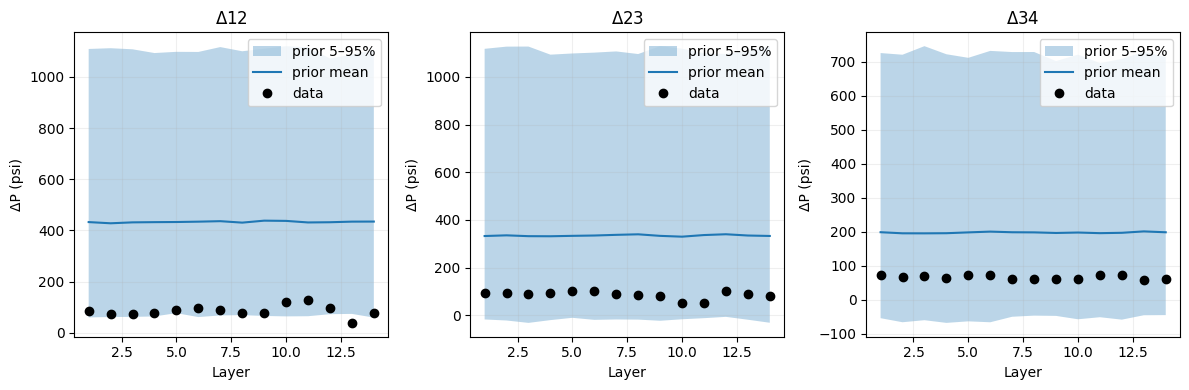

In [70]:
pp_prior = prior_predictive_diffs(F_np, n_draws=1000, seed=42)
layers = np.arange(1, F_np.shape[0] + 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for ax, j, name in zip(
    axes,
    [0, 1, 2],
    [r"$\Delta 12$", r"$\Delta 23$", r"$\Delta 34$"],
):
    if j == 0:
        mean = pp_prior["d12_mean"]; p05 = pp_prior["d12_p05"]; p95 = pp_prior["d12_p95"]
    elif j == 1:
        mean = pp_prior["d23_mean"]; p05 = pp_prior["d23_p05"]; p95 = pp_prior["d23_p95"]
    else:
        mean = pp_prior["d34_mean"]; p05 = pp_prior["d34_p05"]; p95 = pp_prior["d34_p95"]

    ax.fill_between(layers, p05, p95, alpha=0.3, label="prior 5–95%")
    ax.plot(layers, mean, "-", label="prior mean")
    ax.plot(layers, D_np[:, j], "ko", label="data")  # D_np in psi

    ax.set_title(name)
    ax.set_xlabel("Layer")
    ax.set_ylabel("ΔP (psi)")
    ax.grid(alpha=0.2)
    ax.legend()

plt.tight_layout()
plt.show()


In [65]:
import numpy as np
import jax.numpy as jnp

# flows per layer (L,4)
F_jax = jnp.asarray(F_np, dtype=jnp.float32)

# pick the centre of your priors
x1_c = 0.5
x2_c = float(jnp.exp(log_x2_center))
x3_c = float(jnp.exp(log_x3_center))
x4_c = float(jnp.exp(log_x4_center))

d12_pa, d23_pa, d34_pa = gp_diffs_from_F(x1_c, x2_c, x3_c, x4_c, F_jax)

print("Δ12 centre (psi):",  np.asarray(d12_pa) / 6894.76)
print("Δ23 centre (psi):",  np.asarray(d23_pa) / 6894.76)
print("Δ34 centre (psi):",  np.asarray(d34_pa) / 6894.76)


Δ12 centre (psi): [343.48914 343.48914 343.48914 343.48914 343.48914 343.48914 343.48914
 343.48914 343.48914 343.48914 343.48914 343.48914 343.48914 343.48914]
Δ23 centre (psi): [187.95622 187.95622 187.95622 187.95622 187.95622 187.95622 187.95622
 187.95622 187.95622 187.95622 187.95622 187.95622 187.95622 187.95622]
Δ34 centre (psi): [131.64142 131.64142 131.64142 131.64142 131.64142 131.64142 131.64142
 131.64142 131.64142 131.64142 131.64142 131.64142 131.64142 131.64142]


In [66]:
import numpy as np
import jax.numpy as jnp

# flows in JAX
F_jax = jnp.asarray(F_np, dtype=jnp.float32)

# prior-centre params (same as you used for the centre check)
x1_c = 0.5
x2_c = float(jnp.exp(log_x2_center))
x3_c = float(jnp.exp(log_x3_center))
x4_c = float(jnp.exp(log_x4_center))

# GP diffs at centre (Pa)
d12_pa_c, d23_pa_c, d34_pa_c = gp_diffs_from_F(x1_c, x2_c, x3_c, x4_c, F_jax)

# convert to psi and take a single representative value (all layers equal)
d12_c_psi = float(np.asarray(d12_pa_c)[0] / 6894.76)
d23_c_psi = float(np.asarray(d23_pa_c)[0] / 6894.76)
d34_c_psi = float(np.asarray(d34_pa_c)[0] / 6894.76)

print("centre Δ’s (psi):", d12_c_psi, d23_c_psi, d34_c_psi)

# empirical mean of the data in psi
D_mean = D_np.mean(axis=0)   # shape (3,)
d12_data_mean = float(D_mean[0])
d23_data_mean = float(D_mean[1])
d34_data_mean = float(D_mean[2])

print("data means (psi):", d12_data_mean, d23_data_mean, d34_data_mean)

# bias centres = (data mean) - (GP centre prediction)
b12_center = d12_data_mean - d12_c_psi
b23_center = d23_data_mean - d23_c_psi
b34_center = d34_data_mean - d34_c_psi

print("bias centres (psi):", b12_center, b23_center, b34_center)


centre Δ’s (psi): 343.48911347167996 187.95621602492326 131.64142044103056
data means (psi): 85.56348419189453 85.94652557373047 65.97434997558594
bias centres (psi): -257.9256292797854 -102.0096904511928 -65.66707046544462
